[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/badaouihakimou/machine-learning-notebooks/blob/main/21_1_cross_validation.ipynb)



# La validation croisée en détail

Le notebook 21 a introduit `cross_val_score(model, X, y, cv=5)`. Ce `cv=5` cachait
une décision : comment découper les données en 5 morceaux ?

Il existe plusieurs façons de le faire, et le bon choix dépend des données. Un
mauvais découpage donne une évaluation fausse on l'a vu avec iris trié par
classe. Ce notebook passe en revue les principaux découpeurs et dit quand utiliser
chacun.

## Le plan

| Section | Le découpeur | Quand l'utiliser |
|---|---|---|
| 1 | `KFold` | le cas général |
| 2 | `StratifiedKFold` | classification, classes déséquilibrées |
| 3 | `LeaveOneOut` | très peu de données |
| 4 | `ShuffleSplit` | contrôler le nombre de tirages |
| 5 | `GroupKFold` | données groupées |
| 6 | `TimeSeriesSplit` | séries temporelles |

## Trois pièges annoncés

`KFold` avec `random_state` mais sans `shuffle=True` lève une erreur : la graine
n'a aucun effet sans mélange.

`cross_val_score` attend une instance du modèle `KNeighborsClassifier()`
avec parenthèses, pas la classe.

Et `GroupKFold(5).get_n_splits()` renvoie juste le nombre `5` : le passer à `cv`
refait un KFold ordinaire, sans tenir compte des groupes.

Prérequis : le notebook 21.

## 1. KFold : le cas général

Chargeons iris et rappelons le principe.

In [83]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
iris = load_iris()
X = iris.data
y = iris.target
print('X :', X.shape)
print('classes :', np.unique(y))

X : (150, 4)
classes : [0 1 2]


`KFold` découpe les données en `k` morceaux (les *plis*). Le modèle est entraîné
`k` fois : chaque fois, un pli sert de validation et les autres d'entraînement.

In [84]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold, cross_val_score
cv = KFold(n_splits=5, shuffle=True, random_state=0)
scores = cross_val_score(KNeighborsClassifier(), X, y, cv=cv)
print('scores :', scores.round(3))
print('moyenne:', scores.mean().round(4))

scores : [0.967 0.9   1.    1.    0.933]
moyenne: 0.96


### Le piège du shuffle et du random_state

Deux erreurs fréquentes se cachent dans cette cellule.

`shuffle=True` est indispensable ici. Iris est trié par classe 50 fleurs de
chaque espèce à la suite. Sans mélange, un pli entier ne contiendrait qu'une seule
espèce, et l'évaluation n'aurait aucun sens. C'est le piège du notebook 21.

`random_state` sans `shuffle` lève une erreur. La graine ne contrôle que le
mélange ; sans mélange, elle n'a rien à contrôler.

In [85]:
try:
    KFold(n_splits=5, random_state=0) # shuffle oublié
except ValueError as e:
    print('ValueError :', str(e)[:95])

ValueError : Setting a random_state has no effect since shuffle is False. You should leave random_state to i


scikit-learn refuse cette combinaison plutôt que de laisser croire à un contrôle
illusoire. La règle : si tu fixes `random_state`, mets aussi `shuffle=True`.

### Le piège des parenthèses

`cross_val_score` attend une instance du modèle, pas la classe.

In [86]:
try:
    cross_val_score(KNeighborsClassifier, X, y, cv=cv) # sans parenthèses
except TypeError as e:
    print('TypeError :', str(e)[:90])

is_classifier
TypeError : Cannot clone object. You should provide an instance of scikit-learn estimator instead of a


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1230: FutureWarning: passing a class to None is deprecated and will be removed in 1.8. Use an instance of the class instead.
  warnings.warn(


`KNeighborsClassifier` est le plan, `KNeighborsClassifier()` l'objet construit la distinction du notebook 09. Sans parenthèses, on passe le plan, et sklearn ne
peut pas l'entraîner.

### Voir les plis

Pour comprendre ce que fait le découpeur, on peut afficher les indices.

In [87]:
petit = np.arange(10)
cv_demo = KFold(n_splits=5, shuffle=False)
for i, (train_idx, test_idx) in enumerate(cv_demo.split(petit)):
    print(f'pli {i+1} : test = {test_idx}, train = {train_idx}')

pli 1 : test = [0 1], train = [2 3 4 5 6 7 8 9]
pli 2 : test = [2 3], train = [0 1 4 5 6 7 8 9]
pli 3 : test = [4 5], train = [0 1 2 3 6 7 8 9]
pli 4 : test = [6 7], train = [0 1 2 3 4 5 8 9]
pli 5 : test = [8 9], train = [0 1 2 3 4 5 6 7]


Chaque pli met de côté 2 indices pour le test, les 8 autres pour l'entraînement.
Sur les 5 plis, chaque donnée sert exactement une fois à la validation.

## 2. StratifiedKFold : préserver les proportions

En classification, `StratifiedKFold` garantit que chaque pli contient la même
proportion de chaque classe que l'ensemble complet.

In [88]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(n_splits=4)
scores = cross_val_score(KNeighborsClassifier(), X, y, cv=cv)
print('scores :', scores.round(3))
print('moyenne:', scores.mean().round(4))

scores : [0.974 0.947 0.946 1.   ]
moyenne: 0.9667


### Pourquoi c'est important

Sur iris, les trois classes sont équilibrées (50 chacune). Mais imaginons un jeu
déséquilibré 90 % d'une classe, 10 % de l'autre, ce qui est fréquent
(fraude, maladie rare).

Un `KFold` ordinaire pourrait, par malchance, créer un pli sans aucun exemple de
la classe rare. `StratifiedKFold` l'empêche en respectant les proportions dans
chaque pli.

In [89]:
# Un jeu déséquilibré : 135 d'une classe, 15 de l'autre
y_desequilibre = np.array([0]*135 + [1]*15)
print('Répartition globale :', np.bincount(y_desequilibre))
for nom, cv in [('KFold', KFold(5, shuffle=True, random_state=1)),
                ('Stratified', StratifiedKFold(5))]:
    tailles = []
    for train_idx, test_idx in cv.split(np.zeros(len(y_desequilibre)), y_desequilibre):
        n_classe1 = (y_desequilibre[test_idx] == 1).sum()
        tailles.append(n_classe1)
    print(f'{nom:<11} : classe rare par pli = {tailles}')

Répartition globale : [135  15]
KFold       : classe rare par pli = [np.int64(2), np.int64(2), np.int64(3), np.int64(6), np.int64(2)]
Stratified  : classe rare par pli = [np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3)]


Avec `StratifiedKFold`, chaque pli contient à peu près le même nombre d'exemples
de la classe rare. Avec `KFold`, ce nombre varie davantage, et un pli pourrait en
manquer.

La règle : en classification, préférer `StratifiedKFold` à `KFold`. C'est
d'ailleurs ce que `cross_val_score` utilise automatiquement quand on passe un
simple `cv=5` avec un classifieur une bonne raison de plus de ne pas s'inquiéter
outre mesure, sauf si on impose un découpeur à la main.

## 3. LeaveOneOut : un exemple à la fois

`LeaveOneOut` est le cas extrême : chaque pli ne met de côté qu'un seul
exemple. Avec n données, cela fait n entraînements.

In [90]:
from sklearn.model_selection import LeaveOneOut
cv = LeaveOneOut()
scores = cross_val_score(KNeighborsClassifier(), X, y, cv=cv)
print('nombre de scores :', len(scores))
print('chaque score vaut 0 ou 1 :', np.unique(scores))
print('moyenne :', scores.mean().round(4))

nombre de scores : 150
chaque score vaut 0 ou 1 : [0. 1.]
moyenne : 0.9667


150 scores pour 150 fleurs. Chaque score vaut 0 ou 1 soit l'unique exemple de
test est bien classé, soit non. La moyenne donne la proportion de réussite.

### Quand l'utiliser, et son coût

`LeaveOneOut` exploite au maximum les données : le modèle s'entraîne à chaque fois
sur presque tout l'ensemble. C'est utile quand on a très peu de données, où
sacrifier 20 % pour un test serait trop coûteux.

Mais le prix est lourd : n entraînements. Sur 150 fleurs, c'est rapide ; sur
100 000 exemples, ce serait 100 000 entraînements irréaliste.

In [91]:
import time
for nom, cv in [('KFold 5', KFold(5, shuffle=True, random_state=0)),
                ('LeaveOneOut', LeaveOneOut())]:
    debut = time.time()
    cross_val_score(KNeighborsClassifier(), X, y, cv=cv)
    print(f'{nom:<12} : {len(list(cv.split(X)))} entraînements, '
          f'{time.time()-debut:.3f} s')

KFold 5      : 5 entraînements, 0.021 s
LeaveOneOut  : 150 entraînements, 0.460 s


`LeaveOneOut` est bien plus lent, pour un résultat souvent proche d'un KFold à 5
ou 10 plis. On le réserve donc aux petits jeux de données.

## 4. ShuffleSplit : contrôler le nombre de tirages

`KFold` lie le nombre de plis à la taille du test : 5 plis signifient 5 tests de
20 %. `ShuffleSplit` découple les deux.

In [92]:
from sklearn.model_selection import ShuffleSplit
cv = ShuffleSplit(n_splits=4, test_size=0.2, random_state=0)
scores = cross_val_score(KNeighborsClassifier(), X, y, cv=cv)
print('scores :', scores.round(3))
print('moyenne:', scores.mean().round(4))

scores : [0.967 1.    0.933 0.967]
moyenne: 0.9667


Ici on demande 4 tirages, chacun avec 20 % en test. À chaque tirage, les données
sont mélangées et re-séparées au hasard.

### La différence avec KFold

Avec `KFold`, les plis sont disjoints : chaque donnée est en test exactement
une fois. Avec `ShuffleSplit`, les tirages sont indépendants : une même donnée
peut se retrouver en test plusieurs fois, ou jamais.

In [93]:
petit = np.arange(10)
print('KFold, chaque indice testé une fois :')
for train, test in KFold(5, shuffle=True, random_state=0).split(petit):
    print('  test =', test)
print('ShuffleSplit, tirages indépendants, recouvrements possibles :')
for train, test in ShuffleSplit(5, test_size=0.2, random_state=0).split(petit):
    print('  test =', test)

KFold, chaque indice testé une fois :
  test = [2 8]
  test = [4 9]
  test = [1 6]
  test = [3 7]
  test = [0 5]
ShuffleSplit, tirages indépendants, recouvrements possibles :
  test = [2 8]
  test = [3 5]
  test = [2 3]
  test = [6 1]
  test = [5 2]


L'avantage de `ShuffleSplit` : on choisit librement le nombre de tirages et la
taille du test, indépendamment l'un de l'autre. On peut faire 100 tirages de 30 %
sur un petit jeu, ce qu'un KFold ne permet pas.

Son inconvénient : aucune garantie que toutes les données soient testées, ni
qu'elles le soient équitablement.

## 5. GroupKFold : quand les données sont groupées

Parfois, des données appartiennent au même groupe et ne doivent pas être
séparées entre train et test. Par exemple : plusieurs photos du même patient,
plusieurs mesures du même capteur.

Si une photo d'un patient est en entraînement et une autre en test, le modèle
peut « reconnaître » le patient plutôt qu'apprendre la vraie tâche une fuite
d'information déguisée.

In [94]:
from sklearn.model_selection import GroupKFold
# Simulons des groupes : 30 patients, 5 mesures chacun
groupes = np.repeat(np.arange(30), 5)
print('exemple de groupes :', groupes[:12], '...')
print('nombre de groupes :', len(np.unique(groupes)))

exemple de groupes : [0 0 0 0 0 1 1 1 1 1 2 2] ...
nombre de groupes : 30


### Le piège de get_n_splits

In [95]:
mauvais = GroupKFold(n_splits=5).get_n_splits()
print('get_n_splits() renvoie :', mauvais, type(mauvais))

get_n_splits() renvoie : 5 <class 'int'>


`get_n_splits()` ne fait pas le découpage : il renvoie juste le nombre de
plis, ici l'entier `5`. Le passer à `cv` refait un KFold ordinaire, et l'effet de
groupe est perdu.

C'est une erreur silencieuse : le code tourne, donne des scores, mais n'a pas
respecté les groupes.

La bonne façon : passer le découpeur lui-même à `cv`, et les groupes via
`groups=`.

In [96]:
gkf = GroupKFold(n_splits=5)
scores = cross_val_score(KNeighborsClassifier(), X, y, cv=gkf, groups=groupes)
print('scores :', scores.round(3))
print('moyenne :', scores.mean().round(4))

scores : [0.933 1.    1.    0.933 0.967]
moyenne : 0.9667


Maintenant, `GroupKFold` garantit qu'aucun groupe n'est à la fois en entraînement
et en test. Chaque patient est entièrement d'un côté ou de l'autre.

On le vérifie :

In [97]:
for i, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=groupes)):
    groupes_train = set(groupes[train_idx])
    groupes_test = set(groupes[test_idx])
    chevauchement = groupes_train & groupes_test
    print(f'pli {i+1} : {len(groupes_test)} groupes en test, '
          f'chevauchement = {len(chevauchement)}')

pli 1 : 6 groupes en test, chevauchement = 0
pli 2 : 6 groupes en test, chevauchement = 0
pli 3 : 6 groupes en test, chevauchement = 0
pli 4 : 6 groupes en test, chevauchement = 0
pli 5 : 6 groupes en test, chevauchement = 0


Zéro chevauchement à chaque pli : aucun groupe n'est des deux côtés. C'est
exactement ce qu'on veut pour une évaluation honnête sur données groupées.

## 6. TimeSeriesSplit : respecter le temps

Pour une série temporelle, mélanger est une faute grave : on prédirait le
passé à partir du futur. `TimeSeriesSplit` respecte l'ordre chronologique.

In [98]:
from sklearn.model_selection import TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)
petit = np.arange(12)
for i, (train_idx, test_idx) in enumerate(tscv.split(petit)):
    print(f'pli {i+1} : train = {train_idx}, test = {test_idx}')

pli 1 : train = [0 1], test = [2 3]
pli 2 : train = [0 1 2 3], test = [4 5]
pli 3 : train = [0 1 2 3 4 5], test = [6 7]
pli 4 : train = [0 1 2 3 4 5 6 7], test = [8 9]
pli 5 : train = [0 1 2 3 4 5 6 7 8 9], test = [10 11]


La logique est différente de tous les autres découpeurs. L'entraînement ne fait
que grandir, et le test est toujours après dans le temps.

Le pli 1 entraîne sur le début et teste sur ce qui suit. Le pli 2 entraîne sur un
peu plus, teste sur la suite. Et ainsi de suite.

Jamais le test n'est antérieur à l'entraînement c'est la seule façon d'évaluer
honnêtement un modèle de prévision. On simule ce qu'on aurait su à chaque instant.

C'est exactement ce qu'il aurait fallu pour le Bitcoin du notebook 18 : un
`KFold` mélangé aurait laissé le modèle « voir » des cours futurs pour prédire le
passé, gonflant artificiellement sa performance.

## 7. Comparer tous les découpeurs

Sur iris, voyons ce que chacun donne.

In [99]:
from sklearn.model_selection import (KFold, StratifiedKFold, LeaveOneOut,
                                     ShuffleSplit)
decoupeurs = {
    'KFold': KFold(5, shuffle=True, random_state=0),
    'StratifiedKFold': StratifiedKFold(5),
    'ShuffleSplit': ShuffleSplit(5, test_size=0.2, random_state=0),
    'LeaveOneOut': LeaveOneOut(),
}
print(f'{"découpeur":<16} {"moyenne":>8} {"écart-type":>11}')
print('-' * 37)
for nom, cv in decoupeurs.items():
    scores = cross_val_score(KNeighborsClassifier(), X, y, cv=cv)
    print(f'{nom:<16} {scores.mean():>8.3f} {scores.std():>11.3f}')

découpeur         moyenne  écart-type
-------------------------------------
KFold               0.960       0.039
StratifiedKFold     0.973       0.025
ShuffleSplit        0.967       0.021
LeaveOneOut         0.967       0.180


Les moyennes sont proches sur un jeu propre et équilibré comme iris, le choix du
découpeur importe peu. La différence se creuse sur des données difficiles :
déséquilibrées (→ Stratified), petites (→ LeaveOneOut), groupées (→ GroupKFold),
ou temporelles (→ TimeSeriesSplit).

`LeaveOneOut` a un écart-type de 0, ce qui trompe : chaque score valant 0 ou 1, la
notion de dispersion entre plis n'a pas le même sens. On regarde uniquement sa
moyenne.

## 8. Mémo

### Choisir son découpeur

| Découpeur | Situation |
|---|---|
| `KFold` | cas général, régression |
| `StratifiedKFold` | classification, surtout déséquilibrée |
| `LeaveOneOut` | très peu de données |
| `ShuffleSplit` | contrôler nombre et taille des tirages |
| `GroupKFold` | données groupées (patients, capteurs) |
| `TimeSeriesSplit` | séries temporelles |

### La syntaxe

```python
from sklearn.model_selection import cross_val_score, KFold

cv = KFold(n_splits=5, shuffle=True, random_state=0)
scores = cross_val_score(Model(), X, y, cv=cv) # avec groupes :
cross_val_score(Model(), X, y, cv=GroupKFold(5), groups=g)
```

### Les pièges

| Situation | Ce qui se passe |
|---|---|
| `random_state` sans `shuffle=True` | `ValueError` |
| `KFold` sans shuffle sur données triées | plis catastrophiques |
| Modèle sans parenthèses | `TypeError` |
| `get_n_splits()` passé à `cv` | refait un KFold, ignore les groupes |
| Mélanger une série temporelle | prédit le passé avec le futur |
| `KFold` sur classes déséquilibrées | un pli peut manquer une classe |

## 9. Exercices

**Exercice 1**

Crée un jeu déséquilibré à 95 % / 5 %. Compare `KFold` et `StratifiedKFold` en
affichant, pour chaque pli, le nombre d'exemples de la classe rare en test.
Montre qu'un `KFold` peut produire un pli sans aucune classe rare.

**Exercice 2**

Sur iris, trace la moyenne du score de validation croisée en fonction du nombre de
plis, de 2 à 20, avec un `StratifiedKFold`. La moyenne se stabilise-t-elle ?
Y a-t-il un intérêt à monter très haut ?

**Exercice 3**

Ce code veut évaluer un modèle sur des données groupées, où chaque groupe est un
patient avec plusieurs mesures :

```python
from sklearn.model_selection import GroupKFold
cv = GroupKFold(n_splits=5).get_n_splits()
scores = cross_val_score(model, X, y, cv=cv, groups=patients)
```

Il ne fait pas ce qu'on croit. Explique ce que `cv` vaut réellement, pourquoi les
groupes sont ignorés, quel risque cela crée, puis corrige.

## Pour continuer

Le notebook suivant porte sur le prétraitement : normaliser les variables, encoder
les catégories. Le KNN utilisé partout ici y sera l'exemple parfait, car il repose
sur des distances une variable à grande échelle écrase les autres tant qu'on
n'a pas normalisé.

On y verra aussi le `Pipeline`, qui enchaîne prétraitement et modèle pour que la
validation croisée de ce notebook reste honnête : le scaler doit être ajusté sur
chaque pli d'entraînement, jamais sur la validation.

In [100]:
# Exercice 1

In [101]:
import numpy as np
from sklearn.model_selection import KFold, StratifiedKFold

# Un jeu à 95 % / 5 % : 95 exemples classe 0, 5 exemples classe 1
np.random.seed(0)
y = np.array([0]*95 + [1]*5)
X = np.random.randn(100, 3)
print('Répartition globale :', np.bincount(y), '-> 5 % de classe rare')
print('KFold (sans stratification) :')
kf = KFold(n_splits=5, shuffle=True, random_state=0)
for i, (train_idx, test_idx) in enumerate(kf.split(X, y)):
    rares = (y[test_idx] == 1).sum()
    marque = '  <- AUCUNE classe rare !' if rares == 0 else ''
    print(f'  pli {i+1} : {rares} rare(s) en test{marque}')

Répartition globale : [95  5] -> 5 % de classe rare
KFold (sans stratification) :
  pli 1 : 1 rare(s) en test
  pli 2 : 1 rare(s) en test
  pli 3 : 0 rare(s) en test  <- AUCUNE classe rare !
  pli 4 : 2 rare(s) en test
  pli 5 : 1 rare(s) en test


In [102]:
print('StratifiedKFold :')
skf = StratifiedKFold(n_splits=5)
for i, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    rares = (y[test_idx] == 1).sum()
    print(f'  pli {i+1} : {rares} rare(s) en test')

StratifiedKFold :
  pli 1 : 1 rare(s) en test
  pli 2 : 1 rare(s) en test
  pli 3 : 1 rare(s) en test
  pli 4 : 1 rare(s) en test
  pli 5 : 1 rare(s) en test


In [103]:
print('StratifiedKFold :')
skf = StratifiedKFold(n_splits=5)
for i, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    rares = (y[test_idx] == 1).sum()
    print(f'  pli {i+1} : {rares} rare(s) en test')

StratifiedKFold :
  pli 1 : 1 rare(s) en test
  pli 2 : 1 rare(s) en test
  pli 3 : 1 rare(s) en test
  pli 4 : 1 rare(s) en test
  pli 5 : 1 rare(s) en test


In [104]:
# Le cas extrême : vérifions combien de rares chaque pli voit à l'ENTRAÎNEMENT
print('Exemples rares vus à l\'entraînement (KFold) :')
for i, (train_idx, test_idx) in enumerate(kf.split(X, y)):
    rares_train = (y[train_idx] == 1).sum()
    print(f'  pli {i+1} : {rares_train} rare(s) sur 5 en entraînement')

Exemples rares vus à l'entraînement (KFold) :
  pli 1 : 4 rare(s) sur 5 en entraînement
  pli 2 : 4 rare(s) sur 5 en entraînement
  pli 3 : 5 rare(s) sur 5 en entraînement
  pli 4 : 3 rare(s) sur 5 en entraînement
  pli 5 : 4 rare(s) sur 5 en entraînement


In [105]:
# Exercice 2

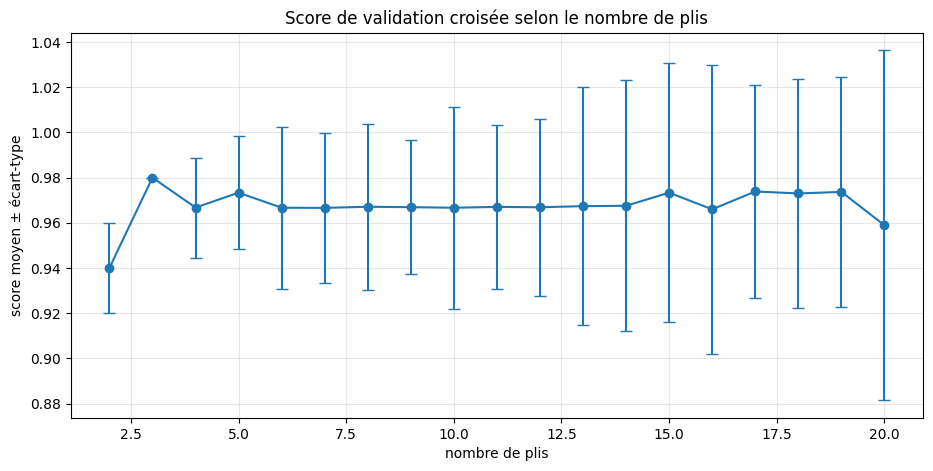

In [106]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
iris = load_iris()
X, y = iris.data, iris.target
k_plis = range(2, 21)
moyennes = []
ecarts = []
for k in k_plis:
    scores = cross_val_score(KNeighborsClassifier(), X, y, cv=StratifiedKFold(k))
    moyennes.append(scores.mean())
    ecarts.append(scores.std())
plt.figure(figsize=(11, 5))
plt.errorbar(list(k_plis), moyennes, yerr=ecarts, marker='o', capsize=4)
plt.xlabel('nombre de plis')
plt.ylabel('score moyen ± écart-type')
plt.title('Score de validation croisée selon le nombre de plis')
plt.grid(alpha=0.3)
plt.show()

In [107]:
for k, m, e in zip([2, 5, 10, 20],
                   [moyennes[0], moyennes[3], moyennes[8], moyennes[18]],
                   [ecarts[0], ecarts[3], ecarts[8], ecarts[18]]):
    print(f'k={k:<3} : moyenne={m:.4f}  écart-type={e:.4f}')

k=2   : moyenne=0.9400  écart-type=0.0200
k=5   : moyenne=0.9733  écart-type=0.0249
k=10  : moyenne=0.9667  écart-type=0.0447
k=20  : moyenne=0.9589  écart-type=0.0774


In [108]:
# Exercice 3

In [109]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, GroupKFold
# Les données
X, y = load_iris(return_X_y=True)
# Un modèle
model = KNeighborsClassifier()
# Des groupes fictifs : 30 patients, 5 mesures chacun
patients = np.repeat(np.arange(30), 5)
# La version correcte
cv = GroupKFold(n_splits=5) # l'objet, pas get_n_splits()
scores = cross_val_score(model, X, y, cv=cv, groups=patients)
print('scores :', scores.round(3))
print('moyenne:', scores.mean().round(4))

scores : [0.933 1.    1.    0.933 0.967]
moyenne: 0.9667


In [110]:
from sklearn.model_selection import GroupKFold
cv = GroupKFold(n_splits=5).get_n_splits()
scores = cross_val_score(model, X, y, cv=cv, groups=patients)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


In [111]:
cv = GroupKFold(n_splits=5).get_n_splits()
print('cv vaut :', cv, type(cv))

cv vaut : 5 <class 'int'>


In [112]:
# Démonstration : cv=5 ignore groups, le résultat est identique sans groups
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.datasets import load_iris
X, y = load_iris(return_X_y=True)
patients = np.repeat(np.arange(30), 5)
avec = cross_val_score(KNeighborsClassifier(), X, y, cv=5, groups=patients)
sans = cross_val_score(KNeighborsClassifier(), X, y, cv=5)
print('avec groups :', avec.round(3))
print('sans groups :', sans.round(3))
print('identiques :', np.array_equal(avec, sans))

avec groups : [0.967 1.    0.933 0.967 1.   ]
sans groups : [0.967 1.    0.933 0.967 1.   ]
identiques : True


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


In [113]:
from sklearn.model_selection import GroupKFold
cv = GroupKFold(n_splits=5) # le découpeur, pas get_n_splits()
scores = cross_val_score(model, X, y, cv=cv, groups=patients)

In [114]:
gkf = GroupKFold(n_splits=5)
for i, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups=patients)):
    groupes_train = set(patients[train_idx])
    groupes_test = set(patients[test_idx])
    chevauchement = groupes_train & groupes_test
    print(f'pli {i+1} : chevauchement de groupes = {len(chevauchement)}')

pli 1 : chevauchement de groupes = 0
pli 2 : chevauchement de groupes = 0
pli 3 : chevauchement de groupes = 0
pli 4 : chevauchement de groupes = 0
pli 5 : chevauchement de groupes = 0


In [115]:
# La version fautive : get_n_splits() renvoie 5, donc groups est ignoré
cv_faux = GroupKFold(n_splits=5).get_n_splits()
print('cv_faux vaut :', cv_faux) # 5, un simple entier
scores_faux = cross_val_score(model, X, y, cv=cv_faux, groups=patients)
scores_sans = cross_val_score(model, X, y, cv=5) # sans groups du tout
print('avec cv=5 et groups :', scores_faux.round(3))
print('avec cv=5 sans groups:', scores_sans.round(3))
print('identiques :', np.array_equal(scores_faux, scores_sans))

cv_faux vaut : 5
avec cv=5 et groups : [0.967 1.    0.933 0.967 1.   ]
avec cv=5 sans groups: [0.967 1.    0.933 0.967 1.   ]
identiques : True


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:877: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(
